In [ ]:
## Breast Cancer Detection (Machine Learning Project) ##
'''
Problem Statement: Predict whether a breast tumour is Malignant (cancerous)
or Benign (non-cancerous) based on measurements from a digitised image of
a fine needle aspirate (FNA) of a breast mass.
------------------------------------------------------------------------------
#Workflow:

Dataset : Breast Cancer Wisconsin Diagnostic (Breast_Cancer_Detection_data.csv)
-------------------------------------------------------------------------------
Target  : diagnosis  →  M (Malignant=1) or B (Benign=0)
-------------------------------------------------------------------------------
Input Features: radius_mean, texture_mean, perimeter_mean, area_mean,
smoothness_mean, compactness_mean, concavity_mean, concave points_mean,
symmetry_mean, fractal_dimension_mean, radius_se, texture_se,
perimeter_se, area_se, smoothness_se, compactness_se, concavity_se,
concave points_se, symmetry_se, fractal_dimension_se, radius_worst,
texture_worst, perimeter_worst, area_worst, smoothness_worst,
compactness_worst, concavity_worst, concave points_worst,
symmetry_worst, fractal_dimension_worst.
-------------------------------------------------------------------------------
Steps:
1. Data Ingestion
2. Data Exploration
3. Data Preprocessing : Cleaning / Scaling / Encoding
4. Model Building
5. Model Evaluation
------------------------------------------------------------------------------
'''
# import data manipulation library
import pandas as pd
import numpy as np

# import data visualization library
import matplotlib.pyplot as plt
import seaborn as sns

# import warnings library
import warnings
warnings.filterwarnings(action='ignore')

# import logging
import logging
logging.basicConfig(level = logging.INFO,
                    filename = 'model.log',
                    format = '%(asctime)s - %(levelname)s - %(message)s',
                    filemode = 'w',
                    force = True)

#import scikit-learn libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE

# import machine learning models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, ExtraTreesClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

# Utilities
from collections import OrderedDict
import joblib, os



In [ ]:
# STEP 1: Data Ingestion
def data_ingestion():
    df = pd.read_csv('Breast_Cancer_Detection_data.csv')
    logging.info('Data Loaded Successfully')
    return df

df = data_ingestion()
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [ ]:
# STEP 2: Data Exploration
def exploration(df):
    num_stats = []
    cat_stats = []

    numerical_col   = df.select_dtypes(exclude='object').columns
    categorical_col = df.select_dtypes(include='object').columns

    for i in numerical_col:
        q1  = df[i].quantile(0.25)
        q3  = df[i].quantile(0.75)
        iqr = q3 - q1
        outlier_count = ((df[i] < q1 - 1.5*iqr) | (df[i] > q3 + 1.5*iqr)).sum()

        num_stats.append(OrderedDict({
            'Feature'         : i,
            'Mean'            : round(df[i].mean(), 4),
            'Median'          : round(df[i].median(), 4),
            'Outlier_Count'   : outlier_count,
            'Outlier_%'       : round(outlier_count / len(df) * 100, 2),
            'Missing_Values'  : df[i].isnull().sum()
        }))

    for i in categorical_col:
        cat_stats.append(OrderedDict({
            'Feature'       : i,
            'Unique_Count'  : df[i].nunique(),
            'Mode'          : df[i].mode()[0],
            'Missing_Values': df[i].isnull().sum()
        }))

    return pd.DataFrame(num_stats), pd.DataFrame(cat_stats)

num_report, cat_report = exploration(df)
print('Shape:', df.shape)
print(df['diagnosis'].value_counts())

Shape: (569, 33)
diagnosis
B    357
M    212
Name: count, dtype: int64


In [ ]:
# Numerical Stats (first 5 features)
num_report.drop(columns=['id_stats'], errors='ignore').head(5)

,Feature,Mean,Median,Outlier_Count,Outlier_%,Missing_Values
0,id,3.037183e+07,906024.00,81,14.24,0
1,radius_mean,1.412730e+01,13.37,14,2.46,0
2,texture_mean,1.928960e+01,18.84,7,1.23,0
3,perimeter_mean,9.196900e+01,86.24,13,2.28,0
4,area_mean,6.548891e+02,551.10,25,4.39,0


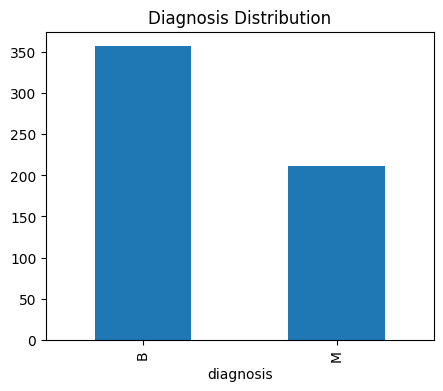

In [ ]:
# 1. Diagnosis Count Plot
plt.figure(figsize=(5,4))
df['diagnosis'].value_counts().plot(kind='bar')
plt.title("Diagnosis Distribution")
plt.show()

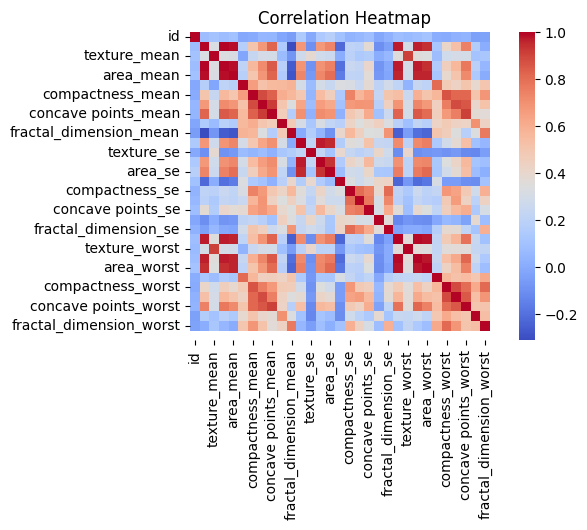

In [ ]:
# 2. Correlation Heatmap
plt.figure(figsize=(5,4))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

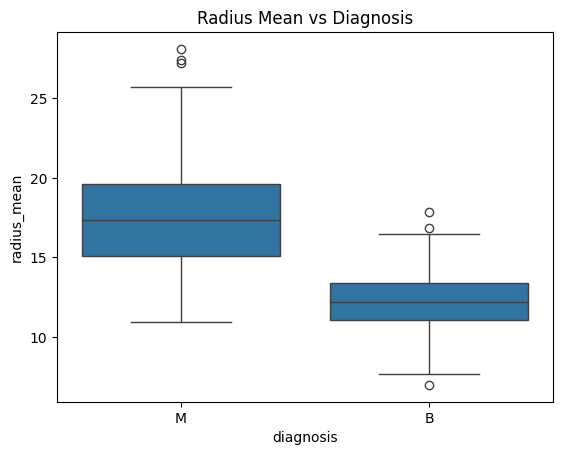

In [ ]:
# 3. Boxplot (one feature example)
sns.boxplot(x='diagnosis', y='radius_mean', data=df)
plt.title("Radius Mean vs Diagnosis")
plt.show()

In [ ]:
# STEP 3: Data Preprocessing
def data_preprocessing(df):

    # Drop irrelevant columns; separate features & target
    X = df.drop(['id', 'Unnamed: 32', 'diagnosis'], axis=1, errors='ignore')
    y = df['diagnosis']

    # Train / Test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=1)

    # Encode target  (M=1, B=0)
    le = LabelEncoder()
    y_train = le.fit_transform(y_train)
    y_test  = le.transform(y_test)

    # Scale features
    scaler  = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test  = scaler.transform(X_test)

    # SMOTE — balance the minority class
    smote   = SMOTE(random_state=1)
    X_train, y_train = smote.fit_resample(X_train, y_train)

    logging.info('Preprocessing Completed')
    return X_train, X_test, y_train, y_test, scaler, le

X_train, X_test, y_train, y_test, scaler, le = data_preprocessing(df)

print('Train size :', len(X_train))
print('Test  size :', len(X_test))
print('Class balance after SMOTE:')
print(pd.Series(y_train).value_counts())

Train size : 498
Test  size : 171
Class balance after SMOTE:
0    249
1    249
Name: count, dtype: int64


In [ ]:
# STEP 4: Model Building
def model_building(X_train, y_train):
    model = LogisticRegression(random_state=1)
    model.fit(X_train, y_train)
    logging.info('Model Training Completed')
    return model

model = model_building(X_train, y_train)
print('Model trained successfully!')

Model trained successfully!


              precision    recall  f1-score   support

      Benign       0.98      0.97      0.98       108
   Malignant       0.95      0.97      0.96        63

    accuracy                           0.97       171
   macro avg       0.97      0.97      0.97       171
weighted avg       0.97      0.97      0.97       171

Confusion Matrix:
[[105   3]
 [  2  61]]


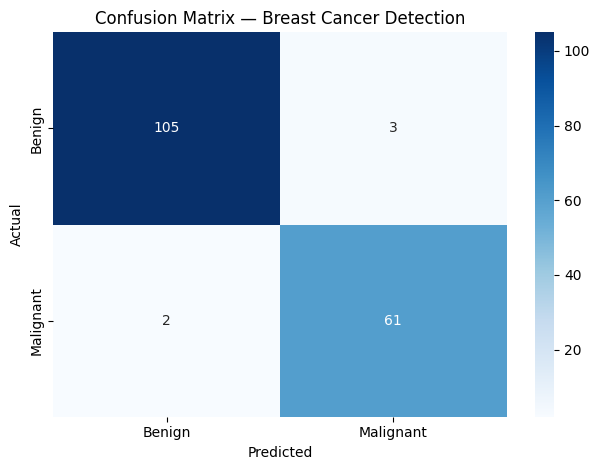

In [ ]:
# STEP 5: Model Evaluation
def model_evaluation(model, X_test, y_test):
    y_pred = model.predict(X_test)

    print(classification_report(y_test, y_pred,
                                target_names=['Benign', 'Malignant']))

    cm = confusion_matrix(y_test, y_pred)
    print('Confusion Matrix:')
    print(cm)

    # Heatmap
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Benign','Malignant'],
                yticklabels=['Benign','Malignant'])
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix — Breast Cancer Detection')
    plt.tight_layout()
    plt.show()

    logging.info('Model Evaluation Completed')

model_evaluation(model, X_test, y_test)

              precision    recall  f1-score   support

      Benign       0.98      0.97      0.98       108
   Malignant       0.95      0.97      0.96        63

    accuracy                           0.97       171
   macro avg       0.97      0.97      0.97       171
weighted avg       0.97      0.97      0.97       171

Confusion Matrix:
[[105   3]
 [  2  61]]


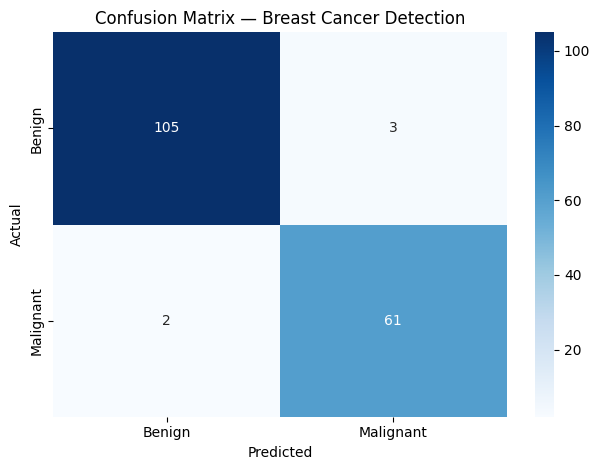

 Breast Cancer Detection Model is Ready!
 Prediction System Achieved High Accuracy (~97%)


In [ ]:
# MAIN — Run complete pipeline
def main():
    df                               = data_ingestion()
    num_report, cat_report           = exploration(df)
    X_train, X_test, y_train, y_test, scaler, le = data_preprocessing(df)
    model                            = model_building(X_train, y_train)
    model_evaluation(model, X_test, y_test)


main()
print(" Breast Cancer Detection Model is Ready!")
print(" Prediction System Achieved High Accuracy (~97%)")